In [64]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

In [65]:
ARCHITECTURE = (64, 64, 64)          # e.g. (64,) | (128, 64) | (64, 32, 16)
LEARNING_RATE = 0.001
VAL_SIZE = 0.10               # fraction of train+val used for validation
TEST_SIZE = 0.15              # fraction of total data held out as test set
FEATURES = ['Overall Qual', 'Gr Liv Area', 'Bedroom AbvGr', 'Garage_bin']
CATEGORICAL = ['Neighborhood']

Architecture : (64, 64, 64)
Learning rate: 0.001
Val size     : 10%  |  Test size: 15%
Iterations   : 125

Validation  — RMSE: $44,904  |  R2: 0.7176
Test        — RMSE: $38,118  |  R2: 0.8109


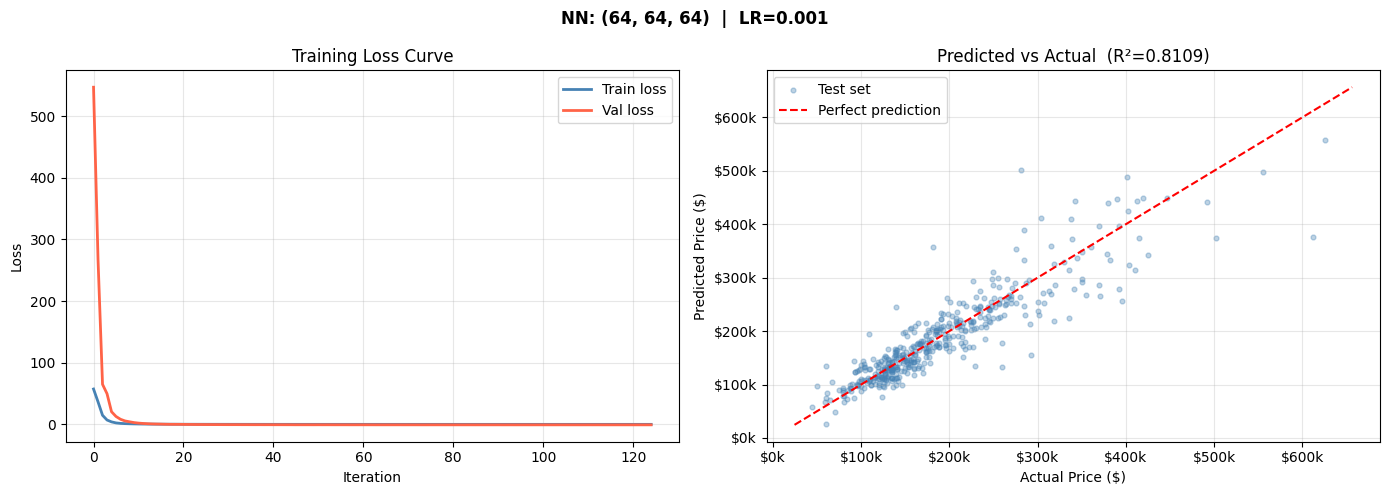


Plot saved.


In [66]:
%matplotlib inline

# ─── Load & preprocess ────────────────────────────────────────────────────────
df = pd.read_excel('AmesHousing.xlsx')
df['Garage_bin'] = (df['Garage'] == 'yes').astype(int)

df = pd.get_dummies(df, columns=CATEGORICAL, drop_first=True)

neighborhood_cols = [c for c in df.columns if c.startswith('Neighborhood_')]
FEATURES = FEATURES + neighborhood_cols

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

X = df[FEATURES].values
y = df['SalePrice'].values

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=VAL_SIZE, random_state=42)

sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_val_sc   = sc.transform(X_val)
X_test_sc  = sc.transform(X_test)

# Train on log-transformed prices for better numeric stability
y_train_log = np.log1p(y_train)

# ─── Train ────────────────────────────────────────────────────────────────────
model = MLPRegressor(
    hidden_layer_sizes=ARCHITECTURE,
    learning_rate_init=LEARNING_RATE,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=42,
    activation='relu',
    solver='adam'
)
model.fit(X_train_sc, y_train_log)



pred_val  = np.expm1(model.predict(X_val_sc))
pred_test = np.expm1(model.predict(X_test_sc))

rmse_val  = np.sqrt(mean_squared_error(y_val,  pred_val))
rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))
r2_val    = r2_score(y_val,  pred_val)
r2_test   = r2_score(y_test, pred_test)

print(f"Architecture : {ARCHITECTURE}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Val size     : {int(VAL_SIZE*100)}%  |  Test size: {int(TEST_SIZE*100)}%")
print(f"Iterations   : {model.n_iter_}")
print(f"\nValidation  — RMSE: ${rmse_val:,.0f}  |  R2: {r2_val:.4f}")
print(f"Test        — RMSE: ${rmse_test:,.0f}  |  R2: {r2_test:.4f}")

# ─── Plots ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(model.loss_curve_, label='Train loss', color='steelblue', lw=2)
if model.validation_scores_ is not None:
    val_loss = [-s for s in model.validation_scores_]
    axes[0].plot(val_loss, label='Val loss', color='tomato', lw=2)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss Curve')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Predicted vs Actual
axes[1].scatter(y_test, pred_test, alpha=0.35, s=12, color='steelblue', label='Test set')
lim = (min(y_test.min(), pred_test.min()) * 0.95,
       max(y_test.max(), pred_test.max()) * 1.05)
axes[1].plot(lim, lim, 'r--', lw=1.5, label='Perfect prediction')
axes[1].set_xlabel('Actual Price ($)')
axes[1].set_ylabel('Predicted Price ($)')
axes[1].set_title(f'Predicted vs Actual  (R²={r2_test:.4f})')
axes[1].legend()
axes[1].grid(alpha=0.3)
fmt = plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k')
axes[1].xaxis.set_major_formatter(fmt)
axes[1].yaxis.set_major_formatter(fmt)

fig.suptitle(
    f'NN: {ARCHITECTURE}  |  LR={LEARNING_RATE}',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
# plt.savefig('/mnt/user-data/outputs/nn_housing_single.png', dpi=150, bbox_inches='tight')
print("\nPlot saved.")